<a href="https://colab.research.google.com/github/MaheeshaSawandi/Safehood/blob/Prediction-Model/XG2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import joblib

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_excel(
    "/content/drive/MyDrive/SafeHood_ML/Dataset/processed_dataset.xlsx"
)

df.head()

,Location,Year,Month,Crime_Count,Average_Severity,Maximum_Severity,Next_Month_Crime,Future_Risk
0,Abhayapura,2016,1,26,6.846154,10,33.0,High
1,Abhayapura,2016,2,33,6.606061,10,19.0,Medium
2,Abhayapura,2016,3,19,7.157895,10,21.0,Medium
3,Abhayapura,2016,4,21,7.000000,10,15.0,Medium
4,Abhayapura,2016,5,15,6.000000,10,28.0,Medium


In [ ]:
print(df.shape)

df.info()

(5638, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5638 entries, 0 to 5637
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Location          5638 non-null   object 
 1   Year              5638 non-null   int64  
 2   Month             5638 non-null   int64  
 3   Crime_Count       5638 non-null   int64  
 4   Average_Severity  5638 non-null   float64
 5   Maximum_Severity  5638 non-null   int64  
 6   Next_Month_Crime  5570 non-null   float64
 7   Future_Risk       5638 non-null   object 
dtypes: float64(2), int64(4), object(2)
memory usage: 352.5+ KB


In [ ]:
df.isnull().sum()

,0
Location,0
Year,0
Month,0
Crime_Count,0
Average_Severity,0
Maximum_Severity,0
Next_Month_Crime,68
Future_Risk,0


In [ ]:
df = df.dropna()

In [ ]:
df["Future_Risk"].value_counts()

,count
Future_Risk,
Medium,2737
Low,2557
High,276


In [ ]:
encoder = LabelEncoder()

df["Location_Code"] = encoder.fit_transform(
    df["Location"]
)

In [ ]:
features = [

    "Location_Code",

    "Year",

    "Month",

    "Crime_Count",

    "Average_Severity",

    "Maximum_Severity"

]

In [ ]:
X = df[features]

y = df["Future_Risk"]

In [ ]:
target_encoder = LabelEncoder()

y_encoded = target_encoder.fit_transform(y)

In [ ]:
target_encoder.classes_

array(['High', 'Low', 'Medium'], dtype=object)

In [ ]:
train = df[df["Year"] <= 2023]

test = df[df["Year"] > 2023]

In [ ]:
X_train = train[features]

X_test = test[features]

In [ ]:
y_train = target_encoder.transform(
    train["Future_Risk"]
)


y_test = target_encoder.transform(
    test["Future_Risk"]
)

In [ ]:
print(X_train.shape)

print(X_test.shape)

(4539, 6)
(1031, 6)


In [ ]:
xgb_model = XGBClassifier(

    n_estimators=500,

    learning_rate=0.5,

    max_depth=5,

    random_state=42,

    objective="multi:softmax",

    num_class=3

)

In [ ]:
xgb_model.fit(

    X_train,

    y_train

)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.5, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_class=3, ...)

In [ ]:
xgb_prediction = xgb_model.predict(

    X_test

)

In [ ]:
accuracy = accuracy_score(

    y_test,

    xgb_prediction

)

print(
"Accuracy:",
accuracy
)

Accuracy: 0.9233753637245393


In [ ]:
precision = precision_score(

    y_test,

    xgb_prediction,

    average="weighted"

)

print(
"Precision:",
precision
)

Precision: 0.9025990596567495


In [ ]:
recall = recall_score(

    y_test,

    xgb_prediction,

    average="weighted"

)

print(
"Recall:",
recall
)

Recall: 0.9233753637245393


In [ ]:
f1 = f1_score(

    y_test,

    xgb_prediction,

    average="weighted"

)

print(
"F1 Score:",
f1
)

F1 Score: 0.9116247128266257


In [ ]:
print(
classification_report(

    y_test,

    xgb_prediction,

    target_names=target_encoder.classes_

)
)

              precision    recall  f1-score   support

        High       0.19      0.09      0.12        56
         Low       0.99      0.99      0.99       445
      Medium       0.90      0.95      0.93       530

    accuracy                           0.92      1031
   macro avg       0.70      0.68      0.68      1031
weighted avg       0.90      0.92      0.91      1031



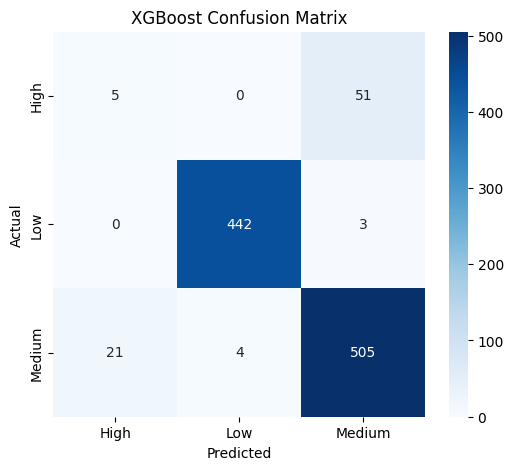

In [ ]:
cm = confusion_matrix(

    y_test,

    xgb_prediction

)


plt.figure(figsize=(6,5))


sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=target_encoder.classes_,

    yticklabels=target_encoder.classes_

)


plt.xlabel(
"Predicted"
)


plt.ylabel(
"Actual"
)


plt.title(
"XGBoost Confusion Matrix"
)


plt.show()

In [ ]:
probabilities = xgb_model.predict_proba(

    X_test

)

In [ ]:
importance = pd.DataFrame({

    "Feature": features,

    "Importance": xgb_model.feature_importances_

})


importance = importance.sort_values(

    by="Importance",

    ascending=False

)


importance

,Feature,Importance
3,Crime_Count,0.794014
0,Location_Code,0.059647
4,Average_Severity,0.038490
5,Maximum_Severity,0.036609
1,Year,0.035919
2,Month,0.035321


In [ ]:
joblib.dump(

    xgb_model,

    "/content/drive/MyDrive/SafeHood_ML/Models/xgboost_model2.pkl"

)


joblib.dump(

    target_encoder,

    "/content/drive/MyDrive/SafeHood_ML/Models/target_encoder2.pkl"

)

['/content/drive/MyDrive/SafeHood_ML/Models/target_encoder2.pkl']